In [1]:
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [2]:


data_path = r"C:\Users\shado\OneDrive\Desktop\KNEE\archive (2)"

for folder in os.listdir(data_path):
    print(folder)


auto_test
test
train
val


In [3]:

samaple_path = r"C:\Users\shado\OneDrive\Desktop\KNEE\archive (2)\train\0\9001695L.png"
img = cv2.imread(samaple_path)

print(img.shape)

(224, 224, 3)


In [4]:
train_path = r"C:\Users\shado\OneDrive\Desktop\KNEE\archive (2)\train"
 
class_counts = {}

for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)
    
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

class_counts

{'0': 2286, '1': 1046, '2': 1516, '3': 757, '4': 173}

Text(0.5, 1.0, 'Class Distribution')

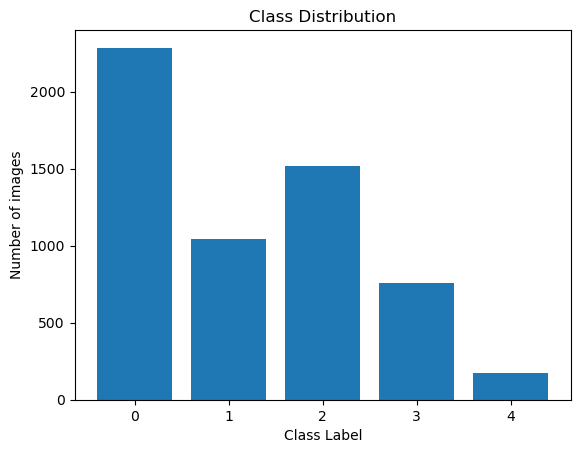

In [5]:
plt.bar(class_counts.keys(),class_counts.values())
plt.xlabel("Class Label")
plt.ylabel("Number of images")
plt.title("Class Distribution")

In [6]:
IMG_SIZE = 224

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

In [7]:
folder = r"C:\Users\shado\OneDrive\Desktop\KNEE\archive (2)\train\0"
files = [f for f in os.listdir(folder) if f.lower().endswith(".png")]

test_img = preprocess_image(os.path.join(folder, files[0]))
print(test_img.shape)
print(test_img.min(), test_img.max())


(224, 224, 3)
0.13725490196078433 0.8980392156862745


In [8]:
data_dir = r"C:\Users\shado\OneDrive\Desktop\KNEE\archive (2)\train"

X = []
y = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    
    if os.path.isdir(class_path):
        for img_name in tqdm(os.listdir(class_path)):
            img_path = os.path.join(class_path, img_name)
            
            img = preprocess_image(img_path)
            X.append(img)
            y.append(int(label))

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

100%|██████████| 173/173 [00:02<00:00, 73.61it/s] 


X shape: (5778, 224, 224, 3)
y shape: (5778,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

y_train = to_categorical(y_train, num_classes=5)
y_test = to_categorical(y_test, num_classes=5)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(4622, 224, 224, 3) (1156, 224, 224, 3)
(4622, 5) (1156, 5)


In [10]:
model = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')
])

model.summary()

c:\Users\shado\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)


Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 526s 4s/step - accuracy: 0.3769 - loss: 1.4667 - val_accuracy: 0.3953 - val_loss: 1.4006
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 367s 3s/step - accuracy: 0.3910 - loss: 1.4279 - val_accuracy: 0.3953 - val_loss: 1.4078
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 64s 439ms/step - accuracy: 0.3905 - loss: 1.4185 - val_accuracy: 0.3953 - val_loss: 1.4027
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 66s 453ms/step - accuracy: 0.3955 - loss: 1.4187 - val_accuracy: 0.3953 - val_loss: 1.4113
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 68s 466ms/step - accuracy: 0.3953 - loss: 1.4140 - val_accuracy: 0.3953 - val_loss: 1.4106
Epoch 6/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 124s 857ms/step - accuracy: 0.3957 - loss: 1.4079 - val_accuracy: 0.3953 - val_loss: 1.3998
Epoch 7/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 113s 755ms/step - accuracy: 0.3957 - loss: 1.4087 - val_accuracy: 0.3953 - val_loss: 1.4007
Epoch 8/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 70s 484ms/step - accuracy: 0.3953 - loss: 1.4

In [ ]:
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])


0.3965815603733063
0.39532873034477234


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

print(confusion_matrix(y_true, y_pred_classes))

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step
              precision    recall  f1-score   support

           0       0.40      1.00      0.57       457
           1       0.00      0.00      0.00       209
           2       0.00      0.00      0.00       303
           3       0.00      0.00      0.00       152
           4       0.00      0.00      0.00        35

    accuracy                           0.40      1156
   macro avg       0.08      0.20      0.11      1156
weighted avg       0.16      0.40      0.22      1156

[[457   0   0   0   0]
 [209   0   0   0   0]
 [303   0   0   0   0]
 [152   0   0   0   0]
 [ 35   0   0   0   0]]


c:\Users\shado\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shado\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\shado\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(0.5055118110236221),
 1: np.float64(1.1047801147227534),
 2: np.float64(0.7622691292875989),
 3: np.float64(1.5265521796565389),
 4: np.float64(6.679768786127168)}

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weights
)
#the accuracy is 30%


Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 62s 424ms/step - accuracy: 0.3946 - loss: 1.6762 - val_accuracy: 0.3953 - val_loss: 1.5324
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 58s 403ms/step - accuracy: 0.3905 - loss: 1.6126 - val_accuracy: 0.3953 - val_loss: 1.5567
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 58s 402ms/step - accuracy: 0.3838 - loss: 1.6101 - val_accuracy: 0.3953 - val_loss: 1.5749
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 59s 404ms/step - accuracy: 0.3074 - loss: 1.6098 - val_accuracy: 0.0337 - val_loss: 1.6123
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 59s 410ms/step - accuracy: 0.3609 - loss: 1.6039 - val_accuracy: 0.2042 - val_loss: 1.5901
Epoch 6/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 59s 404ms/step - accuracy: 0.2542 - loss: 1.6110 - val_accuracy: 0.3962 - val_loss: 1.5942
Epoch 7/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 59s 407ms/step - accuracy: 0.3081 - loss: 1.5995 - val_accuracy: 0.3979 - val_loss: 1.5949
Epoch 8/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 58s 403ms/step - accuracy: 0.2637 - loss: 1

In [ ]:
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])


0.2624405026435852
0.3944636583328247


In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))
print(confusion_matrix(y_true, y_pred_classes))

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step
              precision    recall  f1-score   support

           0       0.40      0.99      0.56       457
           1       0.00      0.00      0.00       209
           2       0.40      0.01      0.01       303
           3       1.00      0.01      0.01       152
           4       0.50      0.03      0.05        35

    accuracy                           0.39      1156
   macro avg       0.46      0.21      0.13      1156
weighted avg       0.41      0.39      0.23      1156

[[452   2   3   0   0]
 [209   0   0   0   0]
 [300   1   2   0   0]
 [149   1   0   1   1]
 [ 34   0   0   0   1]]


In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(5, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weights
)
#the accuracy is 51%


Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 55s 350ms/step - accuracy: 0.3349 - loss: 1.4472 - val_accuracy: 0.2673 - val_loss: 1.4574
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 46s 321ms/step - accuracy: 0.4212 - loss: 1.2080 - val_accuracy: 0.4775 - val_loss: 1.2194
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 45s 311ms/step - accuracy: 0.4489 - loss: 1.1373 - val_accuracy: 0.4991 - val_loss: 1.1784
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 46s 316ms/step - accuracy: 0.4857 - loss: 1.0746 - val_accuracy: 0.4265 - val_loss: 1.3374
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 45s 312ms/step - accuracy: 0.4820 - loss: 1.0529 - val_accuracy: 0.4991 - val_loss: 1.1570
Epoch 6/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 46s 315ms/step - accuracy: 0.5180 - loss: 1.0029 - val_accuracy: 0.4057 - val_loss: 1.2130
Epoch 7/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 46s 316ms/step - accuracy: 0.5106 - loss: 0.9729 - val_accuracy: 0.4801 - val_loss: 1.1418
Epoch 8/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 45s 313ms/step - accuracy: 0.5169 - loss: 0

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))
print(confusion_matrix(y_true, y_pred_classes))

37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 297ms/step
              precision    recall  f1-score   support

           0       0.61      0.76      0.68       457
           1       0.00      0.00      0.00       209
           2       0.42      0.53      0.47       303
           3       0.44      0.37      0.40       152
           4       0.37      0.71      0.49        35

    accuracy                           0.51      1156
   macro avg       0.37      0.48      0.41      1156
weighted avg       0.42      0.51      0.46      1156

[[347   0  95  11   4]
 [129   0  73   5   2]
 [ 84   1 162  46  10]
 [ 11   0  59  56  26]
 [  0   0   1   9  25]]


In [ ]:
model.save("knee_model.keras")